In [ ]:
# install libraries

%pip install duckdb
#!pip -q install duckdb

In [ ]:
# =====================================================
# DUCKDB SQL ANALYTICS
# =====================================================
from google.colab import drive
drive.mount('/content/drive')

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


DATA_PATH = "/content/drive/MyDrive/synthetic_mimic"

master = pd.read_csv(
    f"{DATA_PATH}/master_dataset.csv"
)

print("Dataset Shape:")
print(master.shape)

print("\nFirst 5 Rows:")
print(master.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Shape:
(25059, 35)

First 5 Rows:
   hadm_id  subject_id   admittime   dischtime  los_days admission_type  \
0   200000      100000  2022-01-06  2022-01-23        17         URGENT   
1   200001      100000  2019-11-08  2019-11-20        12       ELECTIVE   
2   200002      100000  2023-09-04  2023-09-23        19       ELECTIVE   
3   200003      100000  2023-06-14  2023-06-28        14         URGENT   
4   200004      100001  2019-08-15  2019-08-23         8    OBSERVATION   

  discharge_location  anchor_age gender      race  ...  CHF  CKD  COPD  \
0            EXPIRED          69      M     ASIAN  ...    0    0     1   
1               HOME          69      M     ASIAN  ...    0    0     1   
2              REHAB          69      M     ASIAN  ...    0    0     1   
3            EXPIRED          69      M     ASIAN  ...    0    0     1   
4       

In [ ]:
# create DUCKDB connection
# =====================================

con = duckdb.connect()
# Register dataframe so SQL can use it
con.register("master", master)


DATA OVERVIEW
----------------------------------------
   admissions  patients    avg_los  avg_resource
0       25059     10000  10.002793     20.365338

QUESTION 1
How Efficiently Is The Hospital Operating?
----------------------------------------

Length of Stay by Admission Type
  admission_type  admissions    avg_los  median_los
0    OBSERVATION        6236  10.067832        10.0
1         URGENT        6210  10.059581        10.0
2       ELECTIVE        6332   9.993051        10.0
3      EMERGENCY        6281   9.891896        10.0


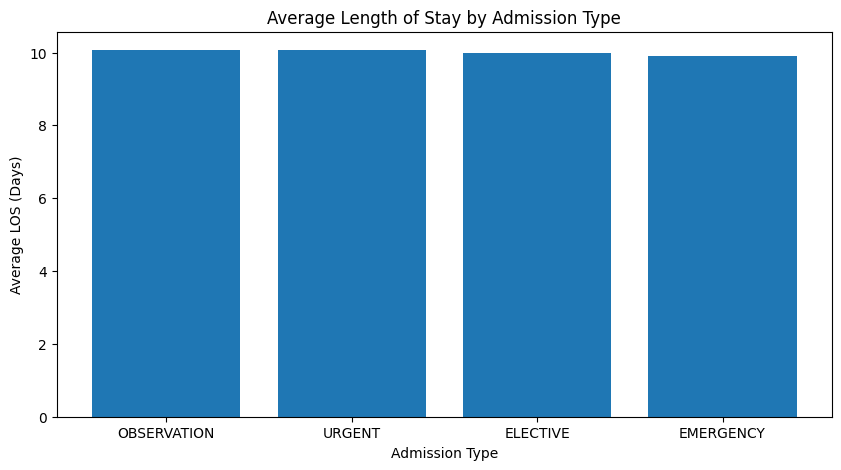


Resource Utilization
  admission_type  avg_resource
0    OBSERVATION     20.428801
1      EMERGENCY     20.427002
2         URGENT     20.331240
3       ELECTIVE     20.275111


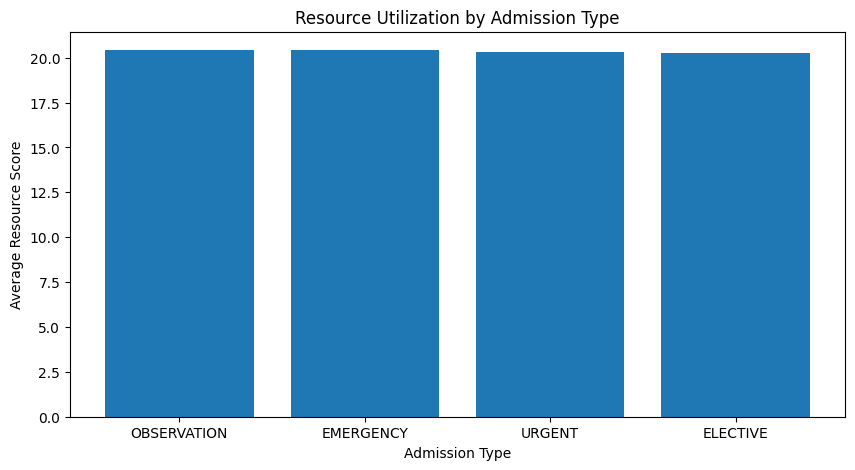


30-Day Readmission Rates
  admission_type  readmission_rate
0         URGENT          0.153623
1      EMERGENCY          0.151727
2    OBSERVATION          0.144965
3       ELECTIVE          0.144188

Average ICU Length of Stay
  admission_type  avg_icu_los
0    OBSERVATION     4.009267
1         URGENT     3.986424
2      EMERGENCY     3.985814
3       ELECTIVE     3.985458

Possible Bottlenecks
  admission_type    avg_los  avg_resource  readmission_rate  avg_icu_los
0    OBSERVATION  10.067832     20.428801          0.144965     4.009267
1         URGENT  10.059581     20.331240          0.153623     3.986424
2       ELECTIVE   9.993051     20.275111          0.144188     3.985458
3      EMERGENCY   9.891896     20.427002          0.151727     3.985814

QUESTION 2
Which Patient Characteristics Are Linked To Poor Outcomes?
----------------------------------------

Age Group Analysis
  age_group  mortality_rate  readmission_rate
0     61-80        0.086541          0.149742
1     41-6

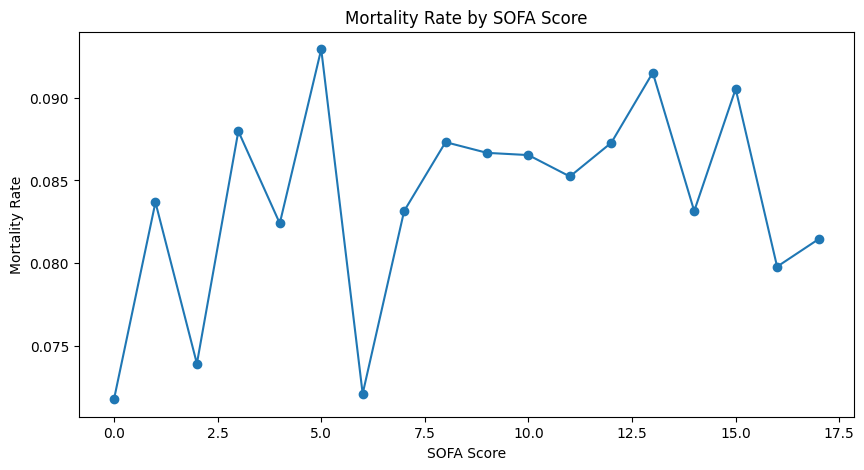


Charlson Index Analysis
   charlson_score  mortality_rate
0             1.0        0.089167
1             2.0        0.080779
2             3.0        0.082456
3             4.0        0.085358


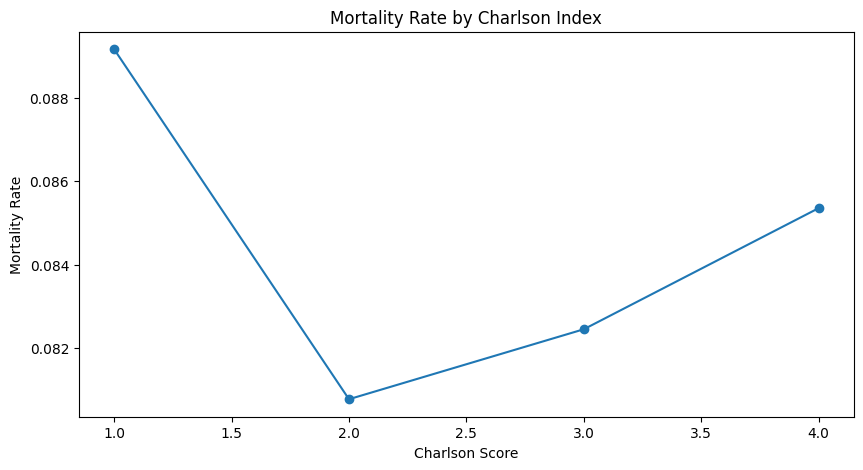


High Risk Groups
  age_group  mortality_rate  sepsis_rate  ventilation_rate
0     61-80        0.086541     0.122310          0.080782
1     41-60        0.085113     0.124110          0.085113
2       80+        0.082770     0.115697          0.082544
3     18-40        0.080635     0.118440          0.076669


In [ ]:
# data overview
# =====================================

print("\nDATA OVERVIEW")
print("-" * 40)

overview_query = """
SELECT
    COUNT(*) AS admissions,
    COUNT(DISTINCT subject_id) AS patients,
    AVG(los_days) AS avg_los,
    AVG(resource_score) AS avg_resource
FROM master
"""

overview = con.execute(overview_query).df()

print(overview)


# QUESTION 1
# HOSPITAL EFFICIENCY
print("\nQUESTION 1")
print("How Efficiently Is The Hospital Operating?")
print("-" * 40)

# length of stay analysis
los_query = """
SELECT
    admission_type,
    COUNT(*) AS admissions,
    AVG(los_days) AS avg_los,
    MEDIAN(los_days) AS median_los
FROM master
GROUP BY admission_type
ORDER BY avg_los DESC
"""

los_df = con.execute(los_query).df()

print("\nLength of Stay by Admission Type")
print(los_df)

# plot
plt.figure(figsize=(10,5))

plt.bar(
    los_df["admission_type"],
    los_df["avg_los"]
)

plt.title("Average Length of Stay by Admission Type")
plt.ylabel("Average LOS (Days)")
plt.xlabel("Admission Type")

plt.show()

# resource utilization
resource_query = """
SELECT
    admission_type,
    AVG(resource_score) AS avg_resource
FROM master
GROUP BY admission_type
ORDER BY avg_resource DESC
"""

resource_df = con.execute(resource_query).df()

print("\nResource Utilization")
print(resource_df)

plt.figure(figsize=(10,5))

plt.bar(
    resource_df["admission_type"],
    resource_df["avg_resource"]
)

plt.title("Resource Utilization by Admission Type")
plt.ylabel("Average Resource Score")
plt.xlabel("Admission Type")

plt.show()

# readmission analysis
readmit_query = """
SELECT
    admission_type,
    AVG(readmit_30d) AS readmission_rate
FROM master
GROUP BY admission_type
ORDER BY readmission_rate DESC
"""

readmit_df = con.execute(readmit_query).df()

print("\n30-Day Readmission Rates")
print(readmit_df)

# ICU analysis
icu_query = """
SELECT
    admission_type,
    AVG(icu_los) AS avg_icu_los
FROM master
GROUP BY admission_type
ORDER BY avg_icu_los DESC
"""

icu_df = con.execute(icu_query).df()

print("\nAverage ICU Length of Stay")
print(icu_df)

# bottleneck analysis
bottleneck_query = """
SELECT
    admission_type,
    AVG(los_days) AS avg_los,
    AVG(resource_score) AS avg_resource,
    AVG(readmit_30d) AS readmission_rate,
    AVG(icu_los) AS avg_icu_los
FROM master
GROUP BY admission_type
ORDER BY avg_los DESC
"""

bottleneck_df = con.execute(bottleneck_query).df()

print("\nPossible Bottlenecks")
print(bottleneck_df)



# QUESTION 2
# POOR OUTCOMES
print("\nQUESTION 2")
print("Which Patient Characteristics Are Linked To Poor Outcomes?")
print("-" * 40)

# age group analysis
age_query = """
SELECT
    age_group,
    AVG(mortality_90d) AS mortality_rate,
    AVG(readmit_30d) AS readmission_rate
FROM master
GROUP BY age_group
ORDER BY mortality_rate DESC
"""

age_df = con.execute(age_query).df()

print("\nAge Group Analysis")
print(age_df)

# sofa score analysis
sofa_query = """
SELECT
    sofa,
    AVG(mortality_90d) AS mortality_rate
FROM master
GROUP BY sofa
ORDER BY sofa
"""

sofa_df = con.execute(sofa_query).df()

print("\nSOFA Score Analysis")
print(sofa_df)

# plot
plt.figure(figsize=(10,5))

plt.plot(
    sofa_df["sofa"],
    sofa_df["mortality_rate"],
    marker="o"
)

plt.title("Mortality Rate by SOFA Score")
plt.xlabel("SOFA Score")
plt.ylabel("Mortality Rate")

plt.show()

# charlson index analysis
charlson_query = """
SELECT
    ROUND(charlson_index) AS charlson_score,
    AVG(mortality_90d) AS mortality_rate
FROM master
GROUP BY charlson_score
ORDER BY charlson_score
"""

charlson_df = con.execute(charlson_query).df()

print("\nCharlson Index Analysis")
print(charlson_df)

plt.figure(figsize=(10,5))

plt.plot(
    charlson_df["charlson_score"],
    charlson_df["mortality_rate"],
    marker="o"
)

plt.title("Mortality Rate by Charlson Index")
plt.xlabel("Charlson Score")
plt.ylabel("Mortality Rate")

plt.show()

# high risk groups
risk_query = """
SELECT
    age_group,
    AVG(mortality_90d) AS mortality_rate,
    AVG(sepsis) AS sepsis_rate,
    AVG(ventilation) AS ventilation_rate
FROM master
GROUP BY age_group
ORDER BY mortality_rate DESC
"""

risk_df = con.execute(risk_query).df()

print("\nHigh Risk Groups")
print(risk_df)

In [ ]:
# correlation analysis
# =====================================

print("\nCorrelation Analysis")
print("-" * 40)

numeric_data = master.select_dtypes(
    include=np.number
)

corr_matrix = numeric_data.corr()

mortality_corr = corr_matrix[
    "mortality_90d"
].sort_values(
    ascending=False
)

print("\nVariables Most Related to Mortality")
print(mortality_corr.head(15))


Correlation Analysis
----------------------------------------

Variables Most Related to Mortality
mortality_90d      1.000000
los_days           0.166417
long_stay          0.146039
mortality          0.029316
icu_los            0.015797
sofa               0.007531
sepsis             0.005899
subject_id         0.005458
hadm_id            0.005453
Diabetes           0.005406
resource_score     0.005344
num_labs           0.004988
num_medications    0.004521
anchor_age         0.004520
COPD               0.003657
Name: mortality_90d, dtype: float64


In [ ]:
# exporting results
# =====================================

los_df.to_csv(
    f"{DATA_PATH}/sql_los_analysis.csv",
    index=False
)

resource_df.to_csv(
    f"{DATA_PATH}/sql_resource_analysis.csv",
    index=False
)

bottleneck_df.to_csv(
    f"{DATA_PATH}/sql_bottlenecks.csv",
    index=False
)

risk_df.to_csv(
    f"{DATA_PATH}/sql_risk_analysis.csv",
    index=False
)

print("\nFiles Saved Successfully")

print("""
Created Files:

sql_los_analysis.csv
sql_resource_analysis.csv
sql_bottlenecks.csv
sql_risk_analysis.csv
""")


Files Saved Successfully

Created Files:

sql_los_analysis.csv
sql_resource_analysis.csv
sql_bottlenecks.csv
sql_risk_analysis.csv

